# Baseline, Stacking, Station-Temporal, And Final Model Selection

This notebook trains leakage-safe baseline models and stacking ensembles on the relaxed RSWQ tabular dataset.

Pipeline:

1. Use the relaxed S2 + context dataset.
2. Evaluate regression targets: `DO`, `BOD`, `Turbidity`, `SS`, `TCB`, and `FCB`.
3. Evaluate NH3 as classification: `NH3_3class` and `NH3_binary`.
4. Compare `S2 only`, `Context only`, and `S2 + Context` feature sets.
5. Run two evaluation designs:
   - Temporal test: train BE 2562-2566, test BE 2567-2568.
   - Station-temporal test: train BE 2562-2566 on train stations, test BE 2567-2568 on held-out stations.
6. Train baseline models: Ridge/Logistic, RandomForest, ExtraTrees, XGBoost, CatBoost.
7. Train leakage-safe stacking ensembles using out-of-fold predictions inside training data only.
8. Select the best model/config per target using temporal performance plus station-temporal robustness.
9. Fit final all-data in-memory models using the selected configs.

Important interpretation:

- Turbidity and SS are optical or near-direct targets.
- DO, BOD, TCB, FCB, and NH3 are proxy/risk targets; do not claim direct Sentinel-2 measurement.
- `SAVE_OUTPUTS=False` by default, so this notebook mainly displays result tables and plots in output cells.


In [1]:

from __future__ import annotations

import os
import math
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, RandomForestClassifier, ExtraTreesClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV, ElasticNet, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    mean_absolute_error,
    r2_score,
)
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, RobustScaler

from xgboost import XGBRegressor, XGBClassifier
from catboost import CatBoostRegressor, CatBoostClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

RANDOM_STATE = 42
PROJECT_ROOT = Path(r"E:\Water Quality Research")
DATA_PATH = PROJECT_ROOT / "Data" / "tabular_data_14" / "train" / "rswq_model_input_relaxed_s2_context_2562_2568.csv"
OLD_AG_TABLE_DIR = PROJECT_ROOT / "Experiments" / "autogluon_tabular" / "reports" / "relaxed_autogluon_old_runs_report" / "tables"

# Keep the notebook output-cell focused. Turn on only if you later want CSV artifacts.
SAVE_OUTPUTS = False
OUTPUT_DIR = PROJECT_ROOT / "Experiments" / "baseline_stack_final" / "notebook_outputs"

# For a quick execution check from terminal:
#   $env:RSWQ_SMOKE_TEST='1'; python -m jupyter nbconvert --execute ...
SMOKE_TEST = os.environ.get("RSWQ_SMOKE_TEST", "0") == "1"

RUN_TEMPORAL = True
RUN_STATION_TEMPORAL = True
RUN_STACKING = True
INCLUDE_CATBOOST = True
INCLUDE_XGBOOST = True
N_STATION_TEMPORAL_FOLDS = 3
N_STACKING_INNER_FOLDS = 3

TREE_N_ESTIMATORS = 80 if SMOKE_TEST else 350
BOOST_N_ESTIMATORS = 80 if SMOKE_TEST else 450
CATBOOST_ITERATIONS = 80 if SMOKE_TEST else 500

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_PATH:", DATA_PATH)
print("SMOKE_TEST:", SMOKE_TEST)
print("SAVE_OUTPUTS:", SAVE_OUTPUTS)


DATA_PATH: E:\Water Quality Research\Data\tabular_data_14\train\rswq_model_input_relaxed_s2_context_2562_2568.csv
SMOKE_TEST: False
SAVE_OUTPUTS: False


## 1. Load Data And Define Leakage-safe Feature Sets

Note: this sklearn baseline notebook uses numeric features only. The earlier AutoGluon notebook counted `season_south_th` as one categorical context feature, but this notebook excludes it and keeps numeric temporal features (`month`, `day_of_year`, `doy_sin`, `doy_cos`) to avoid categorical-encoding leakage/complexity in the baseline comparison.


In [2]:

df = pd.read_csv(DATA_PATH)
df["year_be"] = pd.to_numeric(df["year_be"], errors="coerce")
df["station_canonical"] = df["station_canonical"].astype(str)

REGRESSION_TARGETS = {
    "DO": {"column": "DO_mg_l_clean", "transform": "raw"},
    "BOD": {"column": "BOD_mg_l_clean", "transform": "raw"},
    "Turbidity": {"column": "turbidity_NTU_clean", "transform": "log1p"},
    "SS": {"column": "SS_mg_l_clean", "transform": "log1p"},
    "TCB": {"column": "TCB_MPN_100ml_clean", "transform": "log1p"},
    "FCB": {"column": "FCB_MPN_100ml_clean", "transform": "log1p"},
}

NH3_COLUMN = "NH3_N_mg_l_clean"
NH3_LOW_THRESHOLD = 0.04242640687119285
NH3_MEDIUM_THRESHOLD = 0.12

ALL_TARGET_COLUMNS = [v["column"] for v in REGRESSION_TARGETS.values()] + [NH3_COLUMN]
EXTRA_LEAKAGE_COLUMNS = [
    "WQI_clean", "WQI_reported", "WQI_score_input_complete", "WQI_mean_subindex_pcd5", "WQI_recalc_pcd5",
    "pH_clean", "conductivity_clean", "salinity_ppt_clean", "temp_air_clean", "temp_water_clean",
]

s2_cols = [c for c in df.columns if c.endswith("_median")]
context_prefixes = ("rain_gsmap_", "rainy_hours_gsmap_", "era5h_", "jrc_", "srtm_", "wc_")
context_extra_cols = ["month", "day_of_year", "doy_sin", "doy_cos", "hours_since_last_rain_gsmap_mean"]
context_cols = [c for c in df.columns if c.startswith(context_prefixes)] + [c for c in context_extra_cols if c in df.columns]

numeric_cols = set(df.select_dtypes(include=[np.number]).columns)
blocked = set(ALL_TARGET_COLUMNS + EXTRA_LEAKAGE_COLUMNS)
blocked.update([c for c in df.columns if c.startswith("WQI_")])
blocked.update(["lat", "lon", "latitude", "longitude"])

s2_cols = [c for c in s2_cols if c in numeric_cols and c not in blocked]
context_cols = [c for c in context_cols if c in numeric_cols and c not in blocked and c not in s2_cols]

FEATURE_SETS = {
    "S2 only": s2_cols,
    "Context only": context_cols,
    "S2 + Context": s2_cols + context_cols,
}

for name, cols in FEATURE_SETS.items():
    assert len(cols) == len(set(cols)), f"duplicate columns in {name}"
    forbidden = sorted(set(cols) & blocked)
    assert not forbidden, f"leakage columns in {name}: {forbidden}"

print("Dataset shape:", df.shape)
print("Year counts:")
display(df["year_be"].value_counts().sort_index().to_frame("n"))
print("Feature counts:")
display(pd.DataFrame({"feature_set": list(FEATURE_SETS), "n_features": [len(v) for v in FEATURE_SETS.values()]}))
print("Regression target summary:")
display(df[[v["column"] for v in REGRESSION_TARGETS.values()]].describe().T)


Dataset shape: (390, 226)
Year counts:


,n
year_be,
2562,51
2563,85
2564,57
2565,29
2566,54
2567,68
2568,46


Feature counts:


,feature_set,n_features
0,S2 only,32
1,Context only,106
2,S2 + Context,138


Regression target summary:


,count,mean,std,min,25%,50%,75%,max
DO_mg_l_clean,390.0,6.071923,1.444251,0.000000,5.250000,6.36,7.05,9.55
BOD_mg_l_clean,390.0,1.521026,0.807815,0.100000,1.000000,1.40,1.80,5.40
turbidity_NTU_clean,390.0,38.804744,68.421703,0.000000,7.000000,16.00,40.05,594.00
SS_mg_l_clean,390.0,30.410127,50.867018,7.071068,7.071068,15.00,33.00,612.00
TCB_MPN_100ml_clean,390.0,6332.439161,17145.538853,1.272792,490.000000,1700.00,5400.00,240000.00
FCB_MPN_100ml_clean,390.0,2396.160775,12623.707236,1.272792,130.000000,490.00,1700.00,240000.00


## 2. Define NH3 Labels

In [3]:

def make_nh3_3class(values: pd.Series) -> pd.Series:
    x = pd.to_numeric(values, errors="coerce")
    out = pd.Series(pd.NA, index=x.index, dtype="object")
    out[x <= NH3_LOW_THRESHOLD] = "low_censored"
    out[(x > NH3_LOW_THRESHOLD) & (x <= NH3_MEDIUM_THRESHOLD)] = "medium"
    out[x > NH3_MEDIUM_THRESHOLD] = "high"
    return out


def make_nh3_binary(values: pd.Series) -> pd.Series:
    x = pd.to_numeric(values, errors="coerce")
    out = pd.Series(pd.NA, index=x.index, dtype="object")
    out[x <= NH3_LOW_THRESHOLD] = "low_censored"
    out[x > NH3_LOW_THRESHOLD] = "elevated"
    return out


CLASSIFICATION_TARGETS = {
    "NH3_3class": {"column": NH3_COLUMN, "label_func": make_nh3_3class},
    "NH3_binary": {"column": NH3_COLUMN, "label_func": make_nh3_binary},
}

df["NH3_3class_label"] = make_nh3_3class(df[NH3_COLUMN])
df["NH3_binary_label"] = make_nh3_binary(df[NH3_COLUMN])

print("NH3 class counts overall:")
display(pd.DataFrame({
    "NH3_3class": df["NH3_3class_label"].value_counts(dropna=False),
}).join(df["NH3_binary_label"].value_counts(dropna=False).rename("NH3_binary"), how="outer"))

print("NH3 class counts by temporal split:")
tmp = df.assign(split=np.where(df["year_be"] <= 2566, "train_2562_2566", "test_2567_2568"))
display(pd.crosstab(tmp["split"], tmp["NH3_3class_label"], dropna=False))
display(pd.crosstab(tmp["split"], tmp["NH3_binary_label"], dropna=False))


NH3 class counts overall:


,NH3_3class,NH3_binary
elevated,NaN,169.0
high,110.0,NaN
low_censored,221.0,221.0
medium,59.0,NaN


NH3 class counts by temporal split:


NH3_3class_label,high,low_censored,medium
split,,,
test_2567_2568,47,41,26
train_2562_2566,63,180,33


NH3_binary_label,elevated,low_censored
split,,
test_2567_2568,73,41
train_2562_2566,96,180


## 3. Split Definitions

Temporal test is the primary test. Station-temporal test is the robustness test. Station-temporal folds hold out stations and future years at the same time.


In [4]:

def temporal_split_indices(data: pd.DataFrame):
    train_idx = data.index[data["year_be"] <= 2566].to_numpy()
    test_idx = data.index[data["year_be"] >= 2567].to_numpy()
    assert len(set(train_idx) & set(test_idx)) == 0
    assert data.loc[train_idx, "year_be"].max() <= 2566
    assert data.loc[test_idx, "year_be"].min() >= 2567
    return train_idx, test_idx


def balanced_station_folds(data: pd.DataFrame, n_splits: int = 3):
    test_year = data[data["year_be"] >= 2567].copy()
    counts = test_year.groupby("station_canonical").size().sort_values(ascending=False)
    n_splits = min(n_splits, len(counts))
    folds = [[] for _ in range(n_splits)]
    totals = [0 for _ in range(n_splits)]
    for station, count in counts.items():
        j = int(np.argmin(totals))
        folds[j].append(station)
        totals[j] += int(count)
    return folds


def station_temporal_splits(data: pd.DataFrame, n_splits: int = 3):
    folds = balanced_station_folds(data, n_splits=n_splits)
    splits = []
    for fold_id, heldout_stations in enumerate(folds, start=1):
        heldout = set(heldout_stations)
        train_mask = (data["year_be"] <= 2566) & (~data["station_canonical"].isin(heldout))
        test_mask = (data["year_be"] >= 2567) & (data["station_canonical"].isin(heldout))
        train_idx = data.index[train_mask].to_numpy()
        test_idx = data.index[test_mask].to_numpy()
        assert len(set(data.loc[train_idx, "station_canonical"]) & set(data.loc[test_idx, "station_canonical"])) == 0
        assert data.loc[train_idx, "year_be"].max() <= 2566
        assert data.loc[test_idx, "year_be"].min() >= 2567
        splits.append({
            "fold": fold_id,
            "heldout_stations": sorted(heldout),
            "train_idx": train_idx,
            "test_idx": test_idx,
            "n_train": len(train_idx),
            "n_test": len(test_idx),
        })
    return splits


train_idx, test_idx = temporal_split_indices(df)
station_folds = station_temporal_splits(df, N_STATION_TEMPORAL_FOLDS)

print("Temporal split:", len(train_idx), "train /", len(test_idx), "test")
print("Station-temporal folds:")
display(pd.DataFrame([
    {
        "fold": s["fold"],
        "n_train": s["n_train"],
        "n_test": s["n_test"],
        "n_heldout_stations": len(s["heldout_stations"]),
        "heldout_stations": ", ".join(s["heldout_stations"][:8]) + (" ..." if len(s["heldout_stations"]) > 8 else ""),
    }
    for s in station_folds
]))


Temporal split: 276 train / 114 test
Station-temporal folds:


,fold,n_train,n_test,n_heldout_stations,heldout_stations
0,1,187,38,9,"CP01, LS04, PN02, PN06, SK01, SK03, TP02, TP05..."
1,2,187,38,9,"CP02, LS01, LS03, PN04, SK06, TP03, TP06, TP08..."
2,3,183,38,10,"CP03, LS02, PN01, PN11, PN14, SK02, SK07, SK08..."


## 4. Metrics And Transform Helpers

In [5]:

def transform_y(y, transform: str):
    y = pd.to_numeric(pd.Series(y), errors="coerce").astype(float).to_numpy()
    if transform == "raw":
        return y
    if transform == "log1p":
        return np.log1p(np.clip(y, 0, None))
    raise ValueError(transform)


def inverse_y(y_model, transform: str):
    y_model = np.asarray(y_model, dtype=float)
    if transform == "raw":
        return np.clip(y_model, 0, None)
    if transform == "log1p":
        return np.clip(np.expm1(y_model), 0, None)
    raise ValueError(transform)


def pearson_r(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if len(y_true) < 2 or np.nanstd(y_true) == 0 or np.nanstd(y_pred) == 0:
        return np.nan
    return float(np.corrcoef(y_true, y_pred)[0, 1])


def spearman_r(y_true, y_pred):
    s = pd.DataFrame({"true": y_true, "pred": y_pred}).dropna()
    if len(s) < 2 or s["true"].nunique() < 2 or s["pred"].nunique() < 2:
        return np.nan
    return float(s["true"].corr(s["pred"], method="spearman"))


def regression_metric_dict(y_true_original, y_pred_original, y_true_modelscale, y_pred_modelscale):
    y_true_original = np.asarray(y_true_original, dtype=float)
    y_pred_original = np.asarray(y_pred_original, dtype=float)
    y_true_modelscale = np.asarray(y_true_modelscale, dtype=float)
    y_pred_modelscale = np.asarray(y_pred_modelscale, dtype=float)
    mask = np.isfinite(y_true_original) & np.isfinite(y_pred_original) & np.isfinite(y_true_modelscale) & np.isfinite(y_pred_modelscale)
    if mask.sum() == 0:
        return {k: np.nan for k in [
            "original_n", "original_mae", "original_rmse", "original_r2", "original_pearson_r", "original_spearman_r", "original_bias",
            "modelscale_mae", "modelscale_rmse", "modelscale_r2", "modelscale_pearson_r", "modelscale_spearman_r", "modelscale_bias",
        ]}
    yo = y_true_original[mask]
    po = y_pred_original[mask]
    ym = y_true_modelscale[mask]
    pm = y_pred_modelscale[mask]
    return {
        "original_n": int(mask.sum()),
        "original_mae": float(mean_absolute_error(yo, po)),
        "original_rmse": float(np.sqrt(np.mean((po - yo) ** 2))),
        "original_r2": float(r2_score(yo, po)) if len(yo) >= 2 else np.nan,
        "original_pearson_r": pearson_r(yo, po),
        "original_spearman_r": spearman_r(yo, po),
        "original_bias": float(np.mean(po - yo)),
        "modelscale_mae": float(mean_absolute_error(ym, pm)),
        "modelscale_rmse": float(np.sqrt(np.mean((pm - ym) ** 2))),
        "modelscale_r2": float(r2_score(ym, pm)) if len(ym) >= 2 else np.nan,
        "modelscale_pearson_r": pearson_r(ym, pm),
        "modelscale_spearman_r": spearman_r(ym, pm),
        "modelscale_bias": float(np.mean(pm - ym)),
    }


def classification_metric_dict(y_true, y_pred):
    labels = sorted(set(pd.Series(y_true).dropna()) | set(pd.Series(y_pred).dropna()))
    return {
        "n": int(len(y_true)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", labels=labels, zero_division=0)),
        "labels": labels,
    }


## 5. Model Builders

In [6]:

def make_regression_models():
    models = {
        "DummyMedian": Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", DummyRegressor(strategy="median"))]),
        "Ridge": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
            ("model", RidgeCV(alphas=np.logspace(-3, 3, 13))),
        ]),
        "ElasticNet": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
            ("model", ElasticNet(alpha=0.01, l1_ratio=0.2, max_iter=10000, random_state=RANDOM_STATE)),
        ]),
        "RandomForest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(n_estimators=TREE_N_ESTIMATORS, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1)),
        ]),
        "ExtraTrees": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", ExtraTreesRegressor(n_estimators=TREE_N_ESTIMATORS, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1)),
        ]),
    }
    if INCLUDE_XGBOOST:
        models["XGBoost"] = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", XGBRegressor(
                n_estimators=BOOST_N_ESTIMATORS,
                max_depth=3,
                learning_rate=0.03,
                subsample=0.85,
                colsample_bytree=0.85,
                reg_lambda=2.0,
                objective="reg:squarederror",
                tree_method="hist",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbosity=0,
            )),
        ])
    if INCLUDE_CATBOOST:
        models["CatBoost"] = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", CatBoostRegressor(
                iterations=CATBOOST_ITERATIONS,
                depth=4,
                learning_rate=0.03,
                loss_function="RMSE",
                random_seed=RANDOM_STATE,
                verbose=False,
                allow_writing_files=False,
                thread_count=-1,
            )),
        ])
    return models


def make_classification_models():
    models = {
        "DummyMostFrequent": Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", DummyClassifier(strategy="most_frequent"))]),
        "Logistic": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
            ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)),
        ]),
        "RandomForest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(n_estimators=TREE_N_ESTIMATORS, min_samples_leaf=3, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)),
        ]),
        "ExtraTrees": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", ExtraTreesClassifier(n_estimators=TREE_N_ESTIMATORS, min_samples_leaf=2, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)),
        ]),
    }
    if INCLUDE_XGBOOST:
        models["XGBoost"] = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", XGBClassifier(
                n_estimators=BOOST_N_ESTIMATORS,
                max_depth=3,
                learning_rate=0.03,
                subsample=0.85,
                colsample_bytree=0.85,
                reg_lambda=2.0,
                tree_method="hist",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbosity=0,
            )),
        ])
    if INCLUDE_CATBOOST:
        models["CatBoost"] = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", CatBoostClassifier(
                iterations=CATBOOST_ITERATIONS,
                depth=4,
                learning_rate=0.03,
                loss_function="MultiClass",
                random_seed=RANDOM_STATE,
                verbose=False,
                allow_writing_files=False,
                thread_count=-1,
            )),
        ])
    return models


REG_MODELS = make_regression_models()
CLS_MODELS = make_classification_models()

if SMOKE_TEST:
    REG_MODELS = {k: v for k, v in REG_MODELS.items() if k in ["DummyMedian", "Ridge", "RandomForest"]}
    CLS_MODELS = {k: v for k, v in CLS_MODELS.items() if k in ["DummyMostFrequent", "Logistic", "RandomForest"]}

print("Regression models:", list(REG_MODELS))
print("Classification models:", list(CLS_MODELS))


Regression models: ['DummyMedian', 'Ridge', 'ElasticNet', 'RandomForest', 'ExtraTrees', 'XGBoost', 'CatBoost']
Classification models: ['DummyMostFrequent', 'Logistic', 'RandomForest', 'ExtraTrees', 'XGBoost', 'CatBoost']


## 6. Fit/Predict And Stacking Helpers

In [7]:

def valid_regression_indices(data: pd.DataFrame, target_col: str, indices):
    idx = np.asarray(indices)
    y = pd.to_numeric(data.loc[idx, target_col], errors="coerce")
    return idx[y.notna().to_numpy()]


def fit_predict_regression_model(model, X_train, y_train_model, X_test):
    fitted = clone(model)
    fitted.fit(X_train, y_train_model)
    return fitted, np.asarray(fitted.predict(X_test), dtype=float)


def fit_predict_classification_model(model, X_train, y_train_label, X_test):
    le = LabelEncoder()
    y_enc = le.fit_transform(pd.Series(y_train_label).astype(str))
    if len(le.classes_) < 2:
        return None, None, None, None
    fitted = clone(model)
    fitted.fit(X_train, y_enc)
    pred_enc = fitted.predict(X_test)
    pred_label = le.inverse_transform(np.asarray(pred_enc, dtype=int))
    return fitted, pred_label, le, None


def class_proba_aligned(fitted, X, classes_enc):
    proba = fitted.predict_proba(X)
    model_classes = np.asarray(getattr(fitted, "classes_", classes_enc), dtype=int)
    out = np.zeros((len(X), len(classes_enc)), dtype=float)
    for j, cls in enumerate(model_classes):
        if cls in classes_enc:
            out[:, int(np.where(classes_enc == cls)[0][0])] = proba[:, j]
    row_sum = out.sum(axis=1)
    zero = row_sum == 0
    if zero.any():
        out[zero, :] = 1.0 / len(classes_enc)
        row_sum = out.sum(axis=1)
    return out / row_sum[:, None]


def fit_stacking_regression(X_train, y_train_model, X_test, base_models: dict, n_folds: int = 3):
    base_models = {k: v for k, v in base_models.items() if not k.startswith("Dummy")}
    n = len(X_train)
    n_folds = min(n_folds, max(2, n // 25)) if n >= 50 else 2
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    oof = np.zeros((n, len(base_models)), dtype=float)
    test_base = np.zeros((len(X_test), len(base_models)), dtype=float)
    fitted_bases = {}

    for m_idx, (name, model) in enumerate(base_models.items()):
        for tr_pos, va_pos in kf.split(X_train):
            fitted = clone(model)
            fitted.fit(X_train.iloc[tr_pos], y_train_model[tr_pos])
            oof[va_pos, m_idx] = fitted.predict(X_train.iloc[va_pos])
        full = clone(model)
        full.fit(X_train, y_train_model)
        fitted_bases[name] = full
        test_base[:, m_idx] = full.predict(X_test)

    meta = RidgeCV(alphas=np.logspace(-3, 3, 13))
    meta.fit(oof, y_train_model)
    pred = meta.predict(test_base)
    stack_obj = {"base_models": fitted_bases, "meta_model": meta, "base_names": list(base_models)}
    return stack_obj, pred


def fit_stacking_classifier(X_train, y_train_label, X_test, base_models: dict, n_folds: int = 3):
    base_models = {k: v for k, v in base_models.items() if not k.startswith("Dummy")}
    le = LabelEncoder()
    y_enc = le.fit_transform(pd.Series(y_train_label).astype(str))
    classes_enc = np.arange(len(le.classes_), dtype=int)
    if len(classes_enc) < 2:
        return None, None, None

    class_counts = pd.Series(y_enc).value_counts()
    min_class = int(class_counts.min())
    if min_class < 2:
        return None, None, None
    n_folds = min(n_folds, min_class)
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)

    n = len(X_train)
    block = len(classes_enc)
    oof = np.zeros((n, len(base_models) * block), dtype=float)
    test_base = np.zeros((len(X_test), len(base_models) * block), dtype=float)
    fitted_bases = {}

    for m_idx, (name, model) in enumerate(base_models.items()):
        start = m_idx * block
        end = start + block
        for tr_pos, va_pos in skf.split(X_train, y_enc):
            fitted = clone(model)
            fitted.fit(X_train.iloc[tr_pos], y_enc[tr_pos])
            oof[va_pos, start:end] = class_proba_aligned(fitted, X_train.iloc[va_pos], classes_enc)
        full = clone(model)
        full.fit(X_train, y_enc)
        fitted_bases[name] = full
        test_base[:, start:end] = class_proba_aligned(full, X_test, classes_enc)

    meta = LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)
    meta.fit(oof, y_enc)
    pred_enc = meta.predict(test_base)
    pred_label = le.inverse_transform(pred_enc)
    stack_obj = {"base_models": fitted_bases, "meta_model": meta, "label_encoder": le, "base_names": list(base_models), "classes_enc": classes_enc}
    return stack_obj, pred_label, le


## 7. Evaluation Functions

In [8]:

def evaluate_regression_split(data, target_name, target_info, feature_set_name, feature_cols, train_idx, test_idx, split_name, fold=None):
    target_col = target_info["column"]
    transform = target_info["transform"]
    train_idx = valid_regression_indices(data, target_col, train_idx)
    test_idx = valid_regression_indices(data, target_col, test_idx)
    if len(train_idx) < 30 or len(test_idx) < 5:
        return [], []

    X_train = data.loc[train_idx, feature_cols]
    X_test = data.loc[test_idx, feature_cols]
    y_train_original = pd.to_numeric(data.loc[train_idx, target_col], errors="coerce").to_numpy(dtype=float)
    y_test_original = pd.to_numeric(data.loc[test_idx, target_col], errors="coerce").to_numpy(dtype=float)
    y_train_model = transform_y(y_train_original, transform)
    y_test_model = transform_y(y_test_original, transform)

    rows = []
    preds = []
    for model_name, model in REG_MODELS.items():
        try:
            _, y_pred_model = fit_predict_regression_model(model, X_train, y_train_model, X_test)
            y_pred_original = inverse_y(y_pred_model, transform)
            metrics = regression_metric_dict(y_test_original, y_pred_original, y_test_model, y_pred_model)
            rows.append({
                "split": split_name, "fold": fold, "task": "regression", "target": target_name,
                "feature_set": feature_set_name, "model": model_name, "transform": transform,
                "n_features": len(feature_cols), "n_train": len(train_idx), "n_test": len(test_idx), **metrics,
            })
            preds.append(pd.DataFrame({
                "split": split_name, "fold": fold, "task": "regression", "target": target_name,
                "feature_set": feature_set_name, "model": model_name,
                "sample_id": data.loc[test_idx, "sample_id"].to_numpy(),
                "year_be": data.loc[test_idx, "year_be"].to_numpy(),
                "station_canonical": data.loc[test_idx, "station_canonical"].to_numpy(),
                "y_true_original": y_test_original,
                "y_pred_original": y_pred_original,
                "y_true_modelscale": y_test_model,
                "y_pred_modelscale": y_pred_model,
            }))
        except Exception as e:
            rows.append({
                "split": split_name, "fold": fold, "task": "regression", "target": target_name,
                "feature_set": feature_set_name, "model": model_name, "transform": transform,
                "n_features": len(feature_cols), "n_train": len(train_idx), "n_test": len(test_idx), "error": repr(e),
            })

    if RUN_STACKING and len(REG_MODELS) >= 3:
        try:
            _, y_pred_model = fit_stacking_regression(X_train, y_train_model, X_test, REG_MODELS, n_folds=N_STACKING_INNER_FOLDS)
            y_pred_original = inverse_y(y_pred_model, transform)
            metrics = regression_metric_dict(y_test_original, y_pred_original, y_test_model, y_pred_model)
            rows.append({
                "split": split_name, "fold": fold, "task": "regression", "target": target_name,
                "feature_set": feature_set_name, "model": "Stacking_RidgeMeta", "transform": transform,
                "n_features": len(feature_cols), "n_train": len(train_idx), "n_test": len(test_idx), **metrics,
            })
            preds.append(pd.DataFrame({
                "split": split_name, "fold": fold, "task": "regression", "target": target_name,
                "feature_set": feature_set_name, "model": "Stacking_RidgeMeta",
                "sample_id": data.loc[test_idx, "sample_id"].to_numpy(),
                "year_be": data.loc[test_idx, "year_be"].to_numpy(),
                "station_canonical": data.loc[test_idx, "station_canonical"].to_numpy(),
                "y_true_original": y_test_original,
                "y_pred_original": y_pred_original,
                "y_true_modelscale": y_test_model,
                "y_pred_modelscale": y_pred_model,
            }))
        except Exception as e:
            rows.append({
                "split": split_name, "fold": fold, "task": "regression", "target": target_name,
                "feature_set": feature_set_name, "model": "Stacking_RidgeMeta", "transform": transform,
                "n_features": len(feature_cols), "n_train": len(train_idx), "n_test": len(test_idx), "error": repr(e),
            })

    return rows, preds


def evaluate_classification_split(data, target_name, target_info, feature_set_name, feature_cols, train_idx, test_idx, split_name, fold=None):
    label_func = target_info["label_func"]
    labels = label_func(data[target_info["column"]])
    train_idx = np.asarray(train_idx)
    test_idx = np.asarray(test_idx)
    train_idx = train_idx[labels.loc[train_idx].notna().to_numpy()]
    test_idx = test_idx[labels.loc[test_idx].notna().to_numpy()]
    if len(train_idx) < 30 or len(test_idx) < 5:
        return [], []

    y_train = labels.loc[train_idx].astype(str).to_numpy()
    y_test = labels.loc[test_idx].astype(str).to_numpy()
    if len(np.unique(y_train)) < 2:
        return [], []

    X_train = data.loc[train_idx, feature_cols]
    X_test = data.loc[test_idx, feature_cols]

    rows = []
    preds = []
    for model_name, model in CLS_MODELS.items():
        try:
            _, y_pred, _, _ = fit_predict_classification_model(model, X_train, y_train, X_test)
            if y_pred is None:
                continue
            metrics = classification_metric_dict(y_test, y_pred)
            rows.append({
                "split": split_name, "fold": fold, "task": "classification", "target": target_name,
                "feature_set": feature_set_name, "model": model_name,
                "n_features": len(feature_cols), "n_train": len(train_idx), "n_test": len(test_idx),
                "accuracy": metrics["accuracy"], "balanced_accuracy": metrics["balanced_accuracy"], "macro_f1": metrics["macro_f1"],
            })
            preds.append(pd.DataFrame({
                "split": split_name, "fold": fold, "task": "classification", "target": target_name,
                "feature_set": feature_set_name, "model": model_name,
                "sample_id": data.loc[test_idx, "sample_id"].to_numpy(),
                "year_be": data.loc[test_idx, "year_be"].to_numpy(),
                "station_canonical": data.loc[test_idx, "station_canonical"].to_numpy(),
                "y_true_label": y_test,
                "y_pred_label": y_pred,
            }))
        except Exception as e:
            rows.append({
                "split": split_name, "fold": fold, "task": "classification", "target": target_name,
                "feature_set": feature_set_name, "model": model_name,
                "n_features": len(feature_cols), "n_train": len(train_idx), "n_test": len(test_idx), "error": repr(e),
            })

    if RUN_STACKING and len(CLS_MODELS) >= 3:
        try:
            _, y_pred, _ = fit_stacking_classifier(X_train, y_train, X_test, CLS_MODELS, n_folds=N_STACKING_INNER_FOLDS)
            if y_pred is not None:
                metrics = classification_metric_dict(y_test, y_pred)
                rows.append({
                    "split": split_name, "fold": fold, "task": "classification", "target": target_name,
                    "feature_set": feature_set_name, "model": "Stacking_LogisticMeta",
                    "n_features": len(feature_cols), "n_train": len(train_idx), "n_test": len(test_idx),
                    "accuracy": metrics["accuracy"], "balanced_accuracy": metrics["balanced_accuracy"], "macro_f1": metrics["macro_f1"],
                })
                preds.append(pd.DataFrame({
                    "split": split_name, "fold": fold, "task": "classification", "target": target_name,
                    "feature_set": feature_set_name, "model": "Stacking_LogisticMeta",
                    "sample_id": data.loc[test_idx, "sample_id"].to_numpy(),
                    "year_be": data.loc[test_idx, "year_be"].to_numpy(),
                    "station_canonical": data.loc[test_idx, "station_canonical"].to_numpy(),
                    "y_true_label": y_test,
                    "y_pred_label": y_pred,
                }))
        except Exception as e:
            rows.append({
                "split": split_name, "fold": fold, "task": "classification", "target": target_name,
                "feature_set": feature_set_name, "model": "Stacking_LogisticMeta",
                "n_features": len(feature_cols), "n_train": len(train_idx), "n_test": len(test_idx), "error": repr(e),
            })

    return rows, preds


## 8. Run Temporal And Station-temporal Experiments

In [9]:

reg_targets_to_run = list(REGRESSION_TARGETS)
cls_targets_to_run = list(CLASSIFICATION_TARGETS)
feature_sets_to_run = list(FEATURE_SETS)

if SMOKE_TEST:
    reg_targets_to_run = ["DO"]
    cls_targets_to_run = ["NH3_binary"]
    feature_sets_to_run = ["S2 only"]
    station_folds = station_folds[:1]

all_metric_rows = []
all_pred_frames = []
start = time.time()

if RUN_TEMPORAL:
    print("Running temporal split experiments...")
    for feature_set_name in feature_sets_to_run:
        feature_cols = FEATURE_SETS[feature_set_name]
        for target_name in reg_targets_to_run:
            rows, preds = evaluate_regression_split(
                df, target_name, REGRESSION_TARGETS[target_name], feature_set_name, feature_cols,
                train_idx, test_idx, split_name="temporal", fold=None,
            )
            all_metric_rows.extend(rows)
            all_pred_frames.extend(preds)
        for target_name in cls_targets_to_run:
            rows, preds = evaluate_classification_split(
                df, target_name, CLASSIFICATION_TARGETS[target_name], feature_set_name, feature_cols,
                train_idx, test_idx, split_name="temporal", fold=None,
            )
            all_metric_rows.extend(rows)
            all_pred_frames.extend(preds)

if RUN_STATION_TEMPORAL:
    print("Running station-temporal split experiments...")
    for split in station_folds:
        print("  fold", split["fold"], "n_train", split["n_train"], "n_test", split["n_test"])
        for feature_set_name in feature_sets_to_run:
            feature_cols = FEATURE_SETS[feature_set_name]
            for target_name in reg_targets_to_run:
                rows, preds = evaluate_regression_split(
                    df, target_name, REGRESSION_TARGETS[target_name], feature_set_name, feature_cols,
                    split["train_idx"], split["test_idx"], split_name="station_temporal", fold=split["fold"],
                )
                all_metric_rows.extend(rows)
                all_pred_frames.extend(preds)
            for target_name in cls_targets_to_run:
                rows, preds = evaluate_classification_split(
                    df, target_name, CLASSIFICATION_TARGETS[target_name], feature_set_name, feature_cols,
                    split["train_idx"], split["test_idx"], split_name="station_temporal", fold=split["fold"],
                )
                all_metric_rows.extend(rows)
                all_pred_frames.extend(preds)

metrics_df = pd.DataFrame(all_metric_rows)
preds_df = pd.concat(all_pred_frames, ignore_index=True) if all_pred_frames else pd.DataFrame()

print(f"Finished in {(time.time() - start) / 60:.1f} minutes")
print("metrics_df", metrics_df.shape)
print("preds_df", preds_df.shape)

if "error" in metrics_df.columns:
    err = metrics_df[metrics_df["error"].notna()]
    print("Rows with errors:", len(err))
    if len(err):
        display(err[["split", "fold", "task", "target", "feature_set", "model", "error"]].head(20))


Running temporal split experiments...
Running station-temporal split experiments...
  fold 1 n_train 187 n_test 38
  fold 2 n_train 187 n_test 38
  fold 3 n_train 183 n_test 38
Finished in 14.0 minutes
metrics_df (744, 26)
preds_df (42408, 15)


## 9. Temporal Test Results

In [10]:

valid_metrics = metrics_df.copy()
if "error" in valid_metrics.columns:
    valid_metrics = valid_metrics[valid_metrics["error"].isna() | valid_metrics["error"].isnull()].copy()

reg_temporal = valid_metrics[(valid_metrics["task"] == "regression") & (valid_metrics["split"] == "temporal")].copy()
cls_temporal = valid_metrics[(valid_metrics["task"] == "classification") & (valid_metrics["split"] == "temporal")].copy()

if not reg_temporal.empty:
    display_cols = [
        "target", "feature_set", "model", "transform", "n_features", "n_train", "n_test",
        "original_mae", "original_rmse", "original_r2", "original_pearson_r", "original_spearman_r", "original_bias",
        "modelscale_rmse", "modelscale_r2", "modelscale_spearman_r",
    ]
    print("Best temporal regression rows by target:")
    display(reg_temporal.sort_values(["target", "modelscale_rmse", "original_rmse"]).groupby("target", as_index=False).head(8)[display_cols])

if not cls_temporal.empty:
    print("Best temporal NH3 classification rows:")
    display(cls_temporal.sort_values(["target", "macro_f1", "balanced_accuracy"], ascending=[True, False, False]).groupby("target", as_index=False).head(8)[[
        "target", "feature_set", "model", "n_features", "n_train", "n_test", "accuracy", "balanced_accuracy", "macro_f1"
    ]])


Best temporal regression rows by target:


,target,feature_set,model,transform,n_features,n_train,n_test,original_mae,original_rmse,original_r2,original_pearson_r,original_spearman_r,original_bias,modelscale_rmse,modelscale_r2,modelscale_spearman_r
139,BOD,S2 + Context,Stacking_RidgeMeta,raw,138,276,114,0.547158,0.769931,0.200071,0.474003,0.438324,-0.097729,0.769931,0.200071,0.438324
138,BOD,S2 + Context,CatBoost,raw,138,276,114,0.532970,0.771380,0.197057,0.482386,0.464581,-0.063941,0.771380,0.197057,0.464581
10,BOD,S2 only,ElasticNet,raw,32,276,114,0.560533,0.774919,0.189674,0.450134,0.441566,0.001637,0.774919,0.189674,0.441566
15,BOD,S2 only,Stacking_RidgeMeta,raw,32,276,114,0.548780,0.775462,0.188538,0.437096,0.448917,-0.042995,0.775462,0.188538,0.448917
9,BOD,S2 only,Ridge,raw,32,276,114,0.558400,0.776211,0.186970,0.445207,0.448974,-0.003948,0.776211,0.186970,0.448974
14,BOD,S2 only,CatBoost,raw,32,276,114,0.536509,0.776257,0.186873,0.470875,0.529602,0.028233,0.776257,0.186873,0.529602
135,BOD,S2 + Context,RandomForest,raw,138,276,114,0.538057,0.780283,0.178418,0.450619,0.439809,-0.075650,0.780283,0.178418,0.439809
136,BOD,S2 + Context,ExtraTrees,raw,138,276,114,0.550688,0.792692,0.152078,0.434329,0.432973,-0.108857,0.792692,0.152078,0.432973
127,DO,S2 + Context,RandomForest,raw,138,276,114,0.731550,0.889723,0.420032,0.681132,0.592581,-0.237359,0.889723,0.420032,0.592581
130,DO,S2 + Context,CatBoost,raw,138,276,114,0.725012,0.899947,0.406626,0.682155,0.603981,-0.246524,0.899947,0.406626,0.603981


Best temporal NH3 classification rows:


,target,feature_set,model,n_features,n_train,n_test,accuracy,balanced_accuracy,macro_f1
111,NH3_3class,Context only,Logistic,106,276,114,0.447368,0.423596,0.425020
173,NH3_3class,S2 + Context,Logistic,138,276,114,0.447368,0.419943,0.417567
175,NH3_3class,S2 + Context,ExtraTrees,138,276,114,0.482456,0.435239,0.368461
116,NH3_3class,Context only,Stacking_LogisticMeta,106,276,114,0.403509,0.386019,0.355932
178,NH3_3class,S2 + Context,Stacking_LogisticMeta,138,276,114,0.403509,0.381329,0.347903
113,NH3_3class,Context only,ExtraTrees,106,276,114,0.447368,0.406870,0.333689
51,NH3_3class,S2 only,ExtraTrees,32,276,114,0.368421,0.347771,0.332790
112,NH3_3class,Context only,RandomForest,106,276,114,0.447368,0.407908,0.328688
182,NH3_binary,S2 + Context,ExtraTrees,138,276,114,0.614035,0.682593,0.612963
181,NH3_binary,S2 + Context,RandomForest,138,276,114,0.596491,0.668894,0.594494


## 10. Station-temporal Robustness Results

In [11]:

def flatten_columns(df_in):
    out = df_in.copy()
    out.columns = ["_".join([str(x) for x in col if str(x) != ""]).strip("_") if isinstance(col, tuple) else col for col in out.columns]
    return out


reg_station = valid_metrics[(valid_metrics["task"] == "regression") & (valid_metrics["split"] == "station_temporal")].copy()
cls_station = valid_metrics[(valid_metrics["task"] == "classification") & (valid_metrics["split"] == "station_temporal")].copy()

if not reg_station.empty:
    reg_station_agg = reg_station.groupby(["target", "feature_set", "model", "transform"], as_index=False).agg({
        "n_test": "sum",
        "original_rmse": ["mean", "std"],
        "original_mae": "mean",
        "original_r2": "mean",
        "original_spearman_r": "mean",
        "original_bias": "mean",
        "modelscale_rmse": ["mean", "std"],
        "modelscale_r2": "mean",
        "modelscale_spearman_r": "mean",
    })
    reg_station_agg = flatten_columns(reg_station_agg)
    print("Best station-temporal regression rows by target:")
    display(reg_station_agg.sort_values(["target", "modelscale_rmse_mean", "original_rmse_mean"]).groupby("target", as_index=False).head(8))
else:
    reg_station_agg = pd.DataFrame()

if not cls_station.empty:
    cls_station_agg = cls_station.groupby(["target", "feature_set", "model"], as_index=False).agg({
        "n_test": "sum",
        "accuracy": ["mean", "std"],
        "balanced_accuracy": ["mean", "std"],
        "macro_f1": ["mean", "std"],
    })
    cls_station_agg = flatten_columns(cls_station_agg)
    print("Best station-temporal NH3 classification rows:")
    display(cls_station_agg.sort_values(["target", "macro_f1_mean", "balanced_accuracy_mean"], ascending=[True, False, False]).groupby("target", as_index=False).head(8))
else:
    cls_station_agg = pd.DataFrame()


Best station-temporal regression rows by target:


,target,feature_set,model,transform,n_test_sum,original_rmse_mean,original_rmse_std,original_mae_mean,original_r2_mean,original_spearman_r_mean,original_bias_mean,modelscale_rmse_mean,modelscale_rmse_std,modelscale_r2_mean,modelscale_spearman_r_mean
8,BOD,S2 + Context,CatBoost,raw,114,0.824103,0.148447,0.579174,-0.097096,0.344351,-0.052173,0.824103,0.148447,-0.097096,0.344351
0,BOD,Context only,CatBoost,raw,114,0.855337,0.180405,0.622873,-0.138009,0.197938,-0.148907,0.855337,0.180405,-0.138009,0.197938
15,BOD,S2 + Context,XGBoost,raw,114,0.873813,0.098300,0.623232,-0.342037,0.307937,-0.029517,0.873813,0.098300,-0.342037,0.307937
6,BOD,Context only,Stacking_RidgeMeta,raw,114,0.873410,0.135310,0.630058,-0.219396,0.220690,-0.189426,0.874018,0.135025,-0.220638,0.220690
3,BOD,Context only,ExtraTrees,raw,114,0.876695,0.158664,0.626010,-0.214249,0.184325,-0.207265,0.876695,0.158664,-0.214249,0.184325
4,BOD,Context only,RandomForest,raw,114,0.879588,0.119959,0.637202,-0.262984,0.238371,-0.105563,0.879588,0.119959,-0.262984,0.238371
7,BOD,Context only,XGBoost,raw,114,0.879867,0.130930,0.632541,-0.263577,0.178832,-0.135649,0.879867,0.130930,-0.263577,0.178832
11,BOD,S2 + Context,ExtraTrees,raw,114,0.883700,0.121601,0.607163,-0.400926,0.343239,-0.106094,0.883700,0.121601,-0.400926,0.343239
25,DO,Context only,DummyMedian,raw,114,1.218158,0.190483,0.977719,-0.198020,NaN,-0.188596,1.218158,0.190483,-0.198020,NaN
33,DO,S2 + Context,DummyMedian,raw,114,1.218158,0.190483,0.977719,-0.198020,NaN,-0.188596,1.218158,0.190483,-0.198020,NaN


Best station-temporal NH3 classification rows:


,target,feature_set,model,n_test_sum,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std
12,NH3_3class,S2 + Context,Stacking_LogisticMeta,114,0.447368,0.094883,0.415442,0.055292,0.411940,0.049088
13,NH3_3class,S2 + Context,XGBoost,114,0.456140,0.118664,0.457018,0.096066,0.403798,0.140805
2,NH3_3class,Context only,ExtraTrees,114,0.456140,0.118664,0.427139,0.061754,0.360025,0.124909
6,NH3_3class,Context only,XGBoost,114,0.429825,0.118664,0.424799,0.101821,0.355984,0.148095
5,NH3_3class,Context only,Stacking_LogisticMeta,114,0.394737,0.105263,0.431463,0.171882,0.354836,0.121795
9,NH3_3class,S2 + Context,ExtraTrees,114,0.491228,0.092418,0.437823,0.013671,0.352267,0.045727
3,NH3_3class,Context only,Logistic,114,0.385965,0.075967,0.379571,0.092156,0.343792,0.088324
11,NH3_3class,S2 + Context,RandomForest,114,0.447368,0.069625,0.401705,0.046641,0.327188,0.032834
30,NH3_binary,S2 + Context,ExtraTrees,114,0.631579,0.045580,0.694393,0.023855,0.627105,0.043122
33,NH3_binary,S2 + Context,Stacking_LogisticMeta,114,0.605263,0.026316,0.637256,0.012438,0.600508,0.031249


## 11. Compare Against Old AutoGluon Benchmark

In [12]:

ag_path = OLD_AG_TABLE_DIR / "regression_best_by_target_rmse.csv"
if ag_path.exists():
    old_ag = pd.read_csv(ag_path)
    print("Old AutoGluon best-by-target benchmark:")
    display(old_ag[[
        "target", "feature_set", "best_model", "transform", "original_mae", "original_rmse", "original_r2",
        "original_pearson_r", "original_spearman_r", "modelscale_rmse", "modelscale_r2", "modelscale_spearman_r",
    ]])
else:
    old_ag = pd.DataFrame()
    print("Old AutoGluon benchmark table not found:", ag_path)


Old AutoGluon best-by-target benchmark:


,target,feature_set,best_model,transform,original_mae,original_rmse,original_r2,original_pearson_r,original_spearman_r,modelscale_rmse,modelscale_r2,modelscale_spearman_r
0,BOD,S2 only,WeightedEnsemble_L3,raw,0.506679,0.725601,0.289534,0.548461,0.517062,0.725601,0.289534,0.517062
1,DO,S2 + Context,WeightedEnsemble_L3,raw,0.723324,0.892807,0.416004,0.672975,0.595425,0.892807,0.416004,0.595425
2,FCB,Context only,WeightedEnsemble_L3,log1p,1379.452930,3115.216125,0.029497,0.422332,0.511254,1.720391,0.296511,0.511254
3,SS,S2 + Context,WeightedEnsemble_L2,log1p,16.724097,56.691389,0.136172,0.402452,0.708907,0.621866,0.505070,0.708907
4,TCB,Context only,WeightedEnsemble_L2,log1p,3965.049479,8246.388082,0.109357,0.448682,0.632319,1.473982,0.378635,0.632319
5,Turbidity,S2 + Context,WeightedEnsemble_L2,log1p,22.677512,53.617943,0.273683,0.572618,0.708827,0.766207,0.484110,0.708827


## 12. Final Model/Config Selection

Selection uses temporal test as primary evidence and station-temporal robustness as a check. For `log1p` regression targets, model-scale RMSE is used for ranking because original-scale RMSE is dominated by extreme outliers.


In [13]:

def add_rank_score_regression(reg_temporal, reg_station_agg):
    temp = reg_temporal.copy()
    temp = temp[temp["model"] != "DummyMedian"].copy()
    temp["selection_rmse_temporal"] = np.where(temp["transform"].eq("log1p"), temp["modelscale_rmse"], temp["original_rmse"])
    temp["selection_spearman_temporal"] = temp["original_spearman_r"]

    if not reg_station_agg.empty:
        station = reg_station_agg.copy()
        station["selection_rmse_station"] = np.where(station["transform"].eq("log1p"), station["modelscale_rmse_mean"], station["original_rmse_mean"])
        station["selection_spearman_station"] = station["original_spearman_r_mean"]
        keep_cols = ["target", "feature_set", "model", "selection_rmse_station", "selection_spearman_station", "original_rmse_mean", "modelscale_rmse_mean"]
        temp = temp.merge(station[keep_cols], on=["target", "feature_set", "model"], how="left")
    else:
        temp["selection_rmse_station"] = np.nan
        temp["selection_spearman_station"] = np.nan

    selected_frames = []
    for target, sub in temp.groupby("target"):
        sub = sub.copy()
        sub["rank_temp_rmse"] = sub["selection_rmse_temporal"].rank(method="min", ascending=True)
        sub["rank_temp_spearman"] = sub["selection_spearman_temporal"].rank(method="min", ascending=False)
        if sub["selection_rmse_station"].notna().any():
            sub["rank_station_rmse"] = sub["selection_rmse_station"].rank(method="min", ascending=True)
            sub["rank_station_spearman"] = sub["selection_spearman_station"].rank(method="min", ascending=False)
        else:
            sub["rank_station_rmse"] = 999
            sub["rank_station_spearman"] = 999
        sub["selection_score"] = (
            sub["rank_temp_rmse"] * 1.0 +
            sub["rank_station_rmse"] * 1.0 +
            sub["rank_temp_spearman"] * 0.35 +
            sub["rank_station_spearman"] * 0.35
        )
        selected_frames.append(sub)
    return pd.concat(selected_frames, ignore_index=True)


def add_rank_score_classification(cls_temporal, cls_station_agg):
    temp = cls_temporal.copy()
    temp = temp[temp["model"] != "DummyMostFrequent"].copy()
    if not cls_station_agg.empty:
        keep_cols = ["target", "feature_set", "model", "macro_f1_mean", "balanced_accuracy_mean"]
        temp = temp.merge(cls_station_agg[keep_cols], on=["target", "feature_set", "model"], how="left")
    else:
        temp["macro_f1_mean"] = np.nan
        temp["balanced_accuracy_mean"] = np.nan

    selected_frames = []
    for target, sub in temp.groupby("target"):
        sub = sub.copy()
        sub["rank_temp_f1"] = sub["macro_f1"].rank(method="min", ascending=False)
        sub["rank_temp_balacc"] = sub["balanced_accuracy"].rank(method="min", ascending=False)
        if sub["macro_f1_mean"].notna().any():
            sub["rank_station_f1"] = sub["macro_f1_mean"].rank(method="min", ascending=False)
            sub["rank_station_balacc"] = sub["balanced_accuracy_mean"].rank(method="min", ascending=False)
        else:
            sub["rank_station_f1"] = 999
            sub["rank_station_balacc"] = 999
        sub["selection_score"] = (
            sub["rank_temp_f1"] * 1.0 +
            sub["rank_station_f1"] * 1.0 +
            sub["rank_temp_balacc"] * 0.35 +
            sub["rank_station_balacc"] * 0.35
        )
        selected_frames.append(sub)
    return pd.concat(selected_frames, ignore_index=True)


reg_selection_pool = add_rank_score_regression(reg_temporal, reg_station_agg) if not reg_temporal.empty else pd.DataFrame()
cls_selection_pool = add_rank_score_classification(cls_temporal, cls_station_agg) if not cls_temporal.empty else pd.DataFrame()

if not reg_selection_pool.empty:
    final_regression_selection = reg_selection_pool.sort_values(["target", "selection_score", "selection_rmse_temporal"]).groupby("target", as_index=False).head(1).reset_index(drop=True)
    print("Final selected regression model/config per target:")
    display(final_regression_selection[[
        "target", "feature_set", "model", "transform", "n_features", "selection_score",
        "original_rmse", "original_r2", "original_spearman_r", "modelscale_rmse", "modelscale_r2",
        "selection_rmse_station", "selection_spearman_station",
    ]])
else:
    final_regression_selection = pd.DataFrame()

if not cls_selection_pool.empty:
    final_classification_selection = cls_selection_pool.sort_values(["target", "selection_score", "macro_f1"], ascending=[True, True, False]).groupby("target", as_index=False).head(1).reset_index(drop=True)
    print("Final selected NH3 classification model/config:")
    display(final_classification_selection[[
        "target", "feature_set", "model", "n_features", "selection_score", "accuracy", "balanced_accuracy", "macro_f1",
        "macro_f1_mean", "balanced_accuracy_mean",
    ]])
else:
    final_classification_selection = pd.DataFrame()


Final selected regression model/config per target:


,target,feature_set,model,transform,n_features,selection_score,original_rmse,original_r2,original_spearman_r,modelscale_rmse,modelscale_r2,selection_rmse_station,selection_spearman_station
0,BOD,S2 + Context,CatBoost,raw,138,10.60,0.771380,0.197057,0.464581,0.771380,0.197057,0.824103,0.344351
1,DO,S2 + Context,CatBoost,raw,138,15.15,0.899947,0.406626,0.603981,0.899947,0.406626,1.317116,0.209503
2,FCB,S2 + Context,CatBoost,log1p,138,7.75,3058.423635,0.064560,0.571249,1.658494,0.346222,2.054776,0.220019
3,SS,S2 + Context,RandomForest,log1p,138,8.45,59.043473,0.063006,0.719227,0.641295,0.473661,0.741252,0.538562
4,TCB,S2 + Context,CatBoost,log1p,138,3.05,8475.520324,0.059175,0.656000,1.441585,0.405649,1.748338,0.387942
5,Turbidity,S2 only,Stacking_RidgeMeta,log1p,32,7.10,57.306067,0.170327,0.679349,0.796620,0.442343,0.822927,0.590692


Final selected NH3 classification model/config:


,target,feature_set,model,n_features,selection_score,accuracy,balanced_accuracy,macro_f1,macro_f1_mean,balanced_accuracy_mean
0,NH3_3class,S2 + Context,ExtraTrees,138,10.05,0.482456,0.435239,0.368461,0.352267,0.437823
1,NH3_binary,S2 + Context,ExtraTrees,138,2.70,0.614035,0.682593,0.612963,0.627105,0.694393


## 13. Key Plots

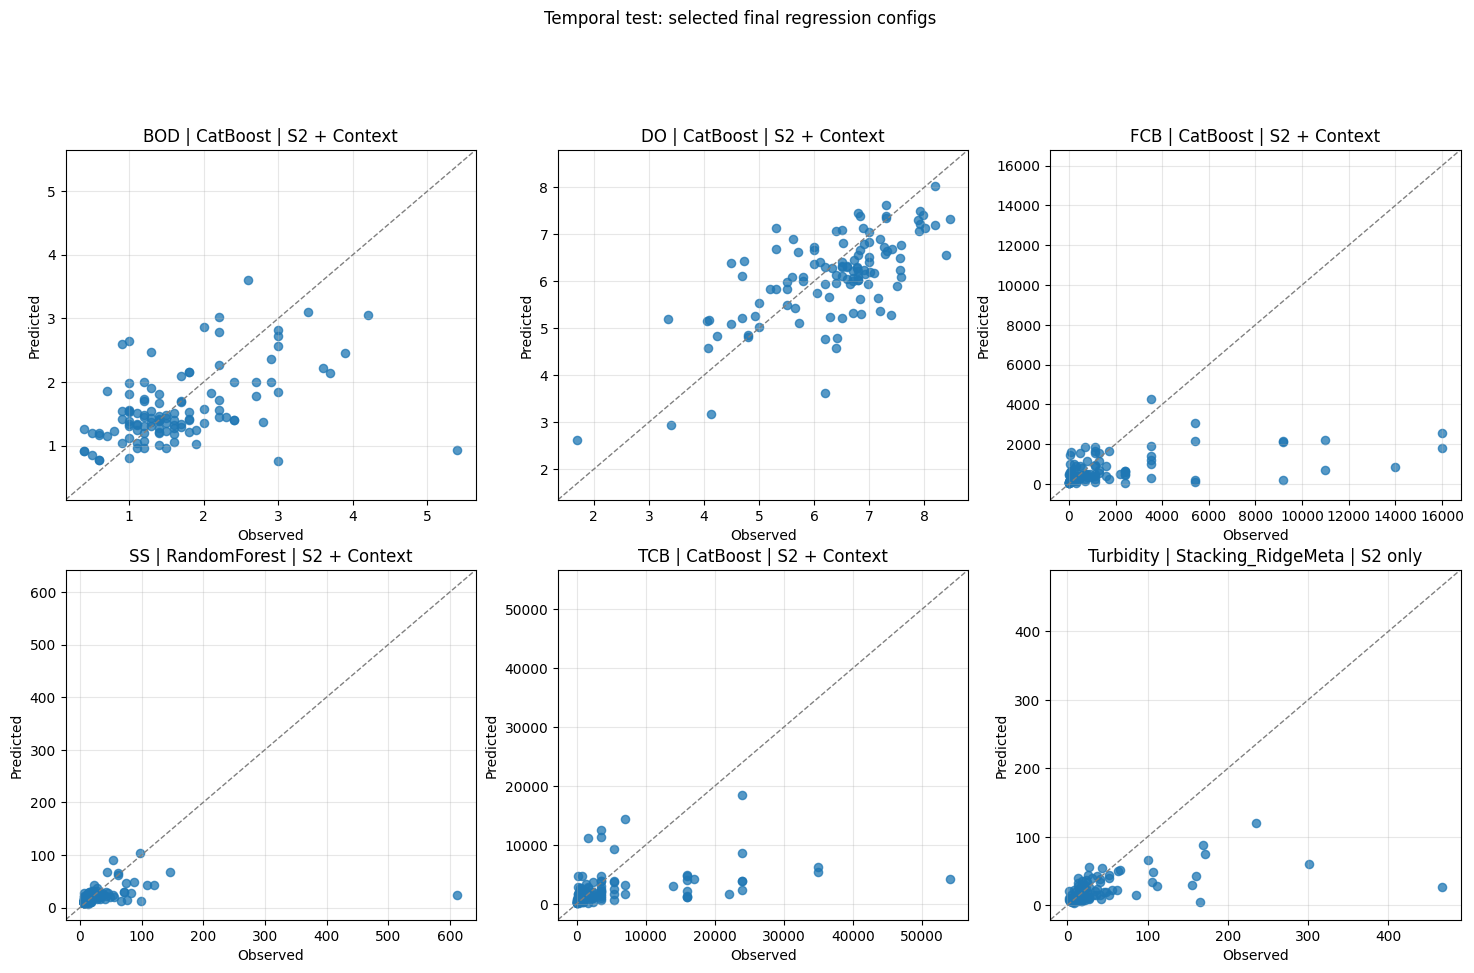

In [14]:

def plot_selected_regression_predictions(preds_df, final_selection):
    if preds_df.empty or final_selection.empty:
        return
    keys = final_selection[["target", "feature_set", "model"]].copy()
    plot_frames = []
    for _, row in keys.iterrows():
        sub = preds_df[
            (preds_df["split"].eq("temporal")) &
            (preds_df["task"].eq("regression")) &
            (preds_df["target"].eq(row["target"])) &
            (preds_df["feature_set"].eq(row["feature_set"])) &
            (preds_df["model"].eq(row["model"]))
        ].copy()
        plot_frames.append(sub)
    plot_df = pd.concat(plot_frames, ignore_index=True) if plot_frames else pd.DataFrame()
    if plot_df.empty:
        return

    targets = list(keys["target"])
    cols = 3
    rows = math.ceil(len(targets) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, target in zip(axes, targets):
        sub = plot_df[plot_df["target"].eq(target)].copy()
        if sub.empty:
            ax.axis("off")
            continue
        x = pd.to_numeric(sub["y_true_original"], errors="coerce")
        y = pd.to_numeric(sub["y_pred_original"], errors="coerce")
        ax.scatter(x, y, alpha=0.75, s=35)
        lo = np.nanmin([x.min(), y.min()])
        hi = np.nanmax([x.max(), y.max()])
        pad = (hi - lo) * 0.05 if hi > lo else 1
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "--", color="gray", linewidth=1)
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
        cfg = keys[keys["target"].eq(target)].iloc[0]
        ax.set_title(f"{target} | {cfg['model']} | {cfg['feature_set']}")
        ax.set_xlabel("Observed")
        ax.set_ylabel("Predicted")
        ax.grid(True, alpha=0.3)
    for ax in axes[len(targets):]:
        ax.axis("off")
    plt.suptitle("Temporal test: selected final regression configs", y=1.02)
    plt.show()


plot_selected_regression_predictions(preds_df, final_regression_selection)


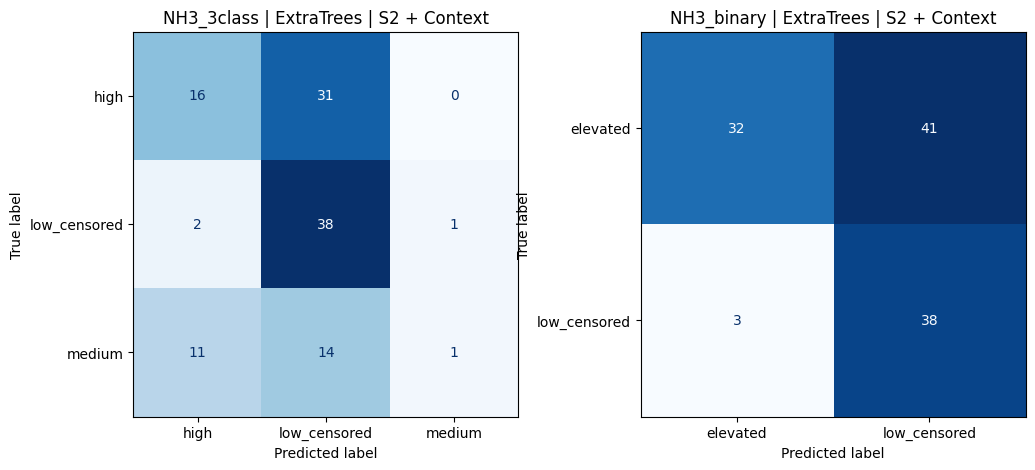

In [15]:

def plot_nh3_confusion(preds_df, final_cls_selection):
    if preds_df.empty or final_cls_selection.empty:
        return
    n = len(final_cls_selection)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, final_cls_selection.iterrows()):
        sub = preds_df[
            (preds_df["split"].eq("temporal")) &
            (preds_df["task"].eq("classification")) &
            (preds_df["target"].eq(row["target"])) &
            (preds_df["feature_set"].eq(row["feature_set"])) &
            (preds_df["model"].eq(row["model"]))
        ].copy()
        if sub.empty:
            ax.axis("off")
            continue
        labels = sorted(set(sub["y_true_label"]) | set(sub["y_pred_label"]))
        cm = confusion_matrix(sub["y_true_label"], sub["y_pred_label"], labels=labels)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        disp.plot(ax=ax, values_format="d", cmap="Blues", colorbar=False)
        ax.set_title(f"{row['target']} | {row['model']} | {row['feature_set']}")
    plt.show()


plot_nh3_confusion(preds_df, final_classification_selection)


## 14. Fit Final All-data Models In Memory

This section fits final models on all available relaxed rows using the selected config. These models are stored in the in-memory `final_models` dictionary only. Nothing is exported unless `SAVE_OUTPUTS=True`.


In [16]:

def train_final_regression_model(data, selected_row):
    target_name = selected_row["target"]
    feature_set = selected_row["feature_set"]
    model_name = selected_row["model"]
    info = REGRESSION_TARGETS[target_name]
    feature_cols = FEATURE_SETS[feature_set]
    valid_idx = valid_regression_indices(data, info["column"], data.index)
    X = data.loc[valid_idx, feature_cols]
    y_original = pd.to_numeric(data.loc[valid_idx, info["column"]], errors="coerce").to_numpy(dtype=float)
    y_model = transform_y(y_original, info["transform"])
    if model_name == "Stacking_RidgeMeta":
        stack_obj, _ = fit_stacking_regression(X, y_model, X.iloc[:1], REG_MODELS, n_folds=N_STACKING_INNER_FOLDS)
        fitted = stack_obj
    else:
        fitted = clone(REG_MODELS[model_name])
        fitted.fit(X, y_model)
    return {"task": "regression", "target": target_name, "feature_set": feature_set, "model": model_name, "transform": info["transform"], "features": feature_cols, "fitted": fitted, "n_train_final": len(valid_idx)}


def train_final_classification_model(data, selected_row):
    target_name = selected_row["target"]
    feature_set = selected_row["feature_set"]
    model_name = selected_row["model"]
    info = CLASSIFICATION_TARGETS[target_name]
    labels = info["label_func"](data[info["column"]])
    valid_idx = data.index[labels.notna()].to_numpy()
    X = data.loc[valid_idx, FEATURE_SETS[feature_set]]
    y_label = labels.loc[valid_idx].astype(str).to_numpy()
    if model_name == "Stacking_LogisticMeta":
        stack_obj, _, _ = fit_stacking_classifier(X, y_label, X.iloc[:1], CLS_MODELS, n_folds=N_STACKING_INNER_FOLDS)
        fitted = stack_obj
        le = stack_obj["label_encoder"] if stack_obj is not None else None
    else:
        le = LabelEncoder()
        y_enc = le.fit_transform(y_label)
        fitted = clone(CLS_MODELS[model_name])
        fitted.fit(X, y_enc)
    return {"task": "classification", "target": target_name, "feature_set": feature_set, "model": model_name, "features": FEATURE_SETS[feature_set], "fitted": fitted, "label_encoder": le, "n_train_final": len(valid_idx)}


final_models = {}
registry_rows = []

for _, row in final_regression_selection.iterrows():
    obj = train_final_regression_model(df, row)
    final_models[obj["target"]] = obj
    registry_rows.append({k: obj[k] for k in ["task", "target", "feature_set", "model", "transform", "n_train_final"]})

for _, row in final_classification_selection.iterrows():
    obj = train_final_classification_model(df, row)
    final_models[obj["target"]] = obj
    registry_rows.append({"task": obj["task"], "target": obj["target"], "feature_set": obj["feature_set"], "model": obj["model"], "transform": "label", "n_train_final": obj["n_train_final"]})

final_registry = pd.DataFrame(registry_rows)
print("Final in-memory models trained:", list(final_models))
display(final_registry)

if SAVE_OUTPUTS:
    metrics_df.to_csv(OUTPUT_DIR / "metrics_all.csv", index=False, encoding="utf-8-sig")
    preds_df.to_csv(OUTPUT_DIR / "predictions_all.csv", index=False, encoding="utf-8-sig")
    final_registry.to_csv(OUTPUT_DIR / "final_model_registry.csv", index=False, encoding="utf-8-sig")
    print("Saved outputs to", OUTPUT_DIR)


Final in-memory models trained: ['BOD', 'DO', 'FCB', 'SS', 'TCB', 'Turbidity', 'NH3_3class', 'NH3_binary']


,task,target,feature_set,model,transform,n_train_final
0,regression,BOD,S2 + Context,CatBoost,raw,390
1,regression,DO,S2 + Context,CatBoost,raw,390
2,regression,FCB,S2 + Context,CatBoost,log1p,390
3,regression,SS,S2 + Context,RandomForest,log1p,390
4,regression,TCB,S2 + Context,CatBoost,log1p,390
5,regression,Turbidity,S2 only,Stacking_RidgeMeta,log1p,390
6,classification,NH3_3class,S2 + Context,ExtraTrees,label,390
7,classification,NH3_binary,S2 + Context,ExtraTrees,label,390


## 15. Research Interpretation Notes

Use the final table with care:

- If temporal performance is good but station-temporal performance is weak, report that the model may not transfer well to unseen stations.
- For `TCB`, `FCB`, and `NH3`, emphasize proxy/risk interpretation rather than direct spectral measurement.
- For `Turbidity` and `SS`, image-patch/CNN experiments are scientifically more defensible than for microbial or nutrient targets.
- If stacking is only marginally better than a single tree/boosting model, prefer the simpler model for interpretability.
